# Simple Linear Regression

**Objective:** Demonstrate the use of simple linear regression

**Author:** Dr. Juan Manuel Ahuactzin Larios

## Regression with the scikit-learn library  
https://scikit-learn.org/

In [1]:
# Data libraries
import math
import pandas as pd
import numpy as np

# Graph
import matplotlib.pyplot as plt
from matplotlib import style

# Processing and models
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# matplotlib configuration
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# warning configuration
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [3]:
data = pd.read_excel("../data/Datos_COVID_por_estado.xlsx", index_col = 0) 

In [4]:
data.head()

,Poblacion,Confirmados,Defunciones,Ficticio
Estado,,,,
AGUASCALIENTES,1434635,26770,2469,87719.439300
BAJA CALIFORNIA,3634868,50697,8728,199655.155359
BAJA CALIFORNIA SUR,804708,39272,1529,120147.197875
CAMPECHE,1000617,11689,1306,38671.443770
CHIAPAS,5730367,12302,1666,155119.581437


## Data Visualization

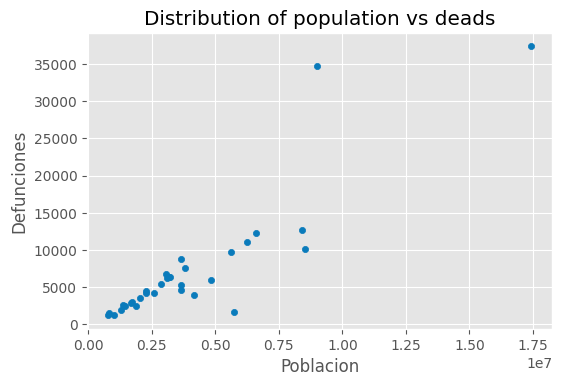

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.84))

data.plot(
    x    = 'Poblacion',
    y    = 'Defunciones',
    c    = '#0A7BBB',
    kind = "scatter",
    ax   = ax
)
ax.set_title('Distribution of population vs deads');

## Running the Linear Regression

In [6]:
X = data[['Poblacion']]
y = data[['Defunciones']]


X_train, X_test, y_train, y_test = train_test_split(
                                        X.values,
                                        y.values,
                                        train_size   = 0.8,  #Size of the training set
                                        random_state = 1966, #Seed for the random number generation
                                        shuffle      = True  #Select aleatory data by shuffling it
                                    )

# Creation of the model
model = LinearRegression()
model.fit(X = X_train, y = y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Printing the Results of the Linear Regression Model

In [7]:
W =  [model.intercept_[0], model.coef_[0][0]]

print(f"Our model is by consequence: y = {W[0]} + {W[1]}*{X.columns[0]}")
print("Coefficient of determination:", model.score(X, y))



Our model is by consequence: y = -1826.1683823703997 + 0.002395521190595699*Poblacion
Coefficient of determination: 0.7589277482957683


## Prediction and Calculation of the Standard Error of the Residuals

In [10]:
predictions = model.predict(X=X_test)
# The output of the model is a 2D array, we need to convert 
# it to a 1D array to compare it with the true values
predictions = np.ravel(predictions)

error = 0
for i in range(len(y_test)):
    print(f" True value vs predicted: {y_test[i,0]} {int(predictions[i])} ")
    error += (y_test[i,0]-predictions[i])**2
print(f"Root Mean Square Error by hand: {math.sqrt(error/len(X_test))}")
  
rmse = root_mean_squared_error(
    y_true=y_test,
    y_pred=predictions
)
print("")
print(f"Root Mean Square Error : {rmse}")

 True value vs predicted: 10139 18631 
 True value vs predicted: 5443 5039 
 True value vs predicted: 9738 11613 
 True value vs predicted: 1221 54 
 True value vs predicted: 37359 39922 
 True value vs predicted: 1873 1260 
 True value vs predicted: 3960 8099 
Root Mean Square Error by hand: 3803.049250306064

Root Mean Square Error : 3803.049250306064


## Visualization of the Predictions

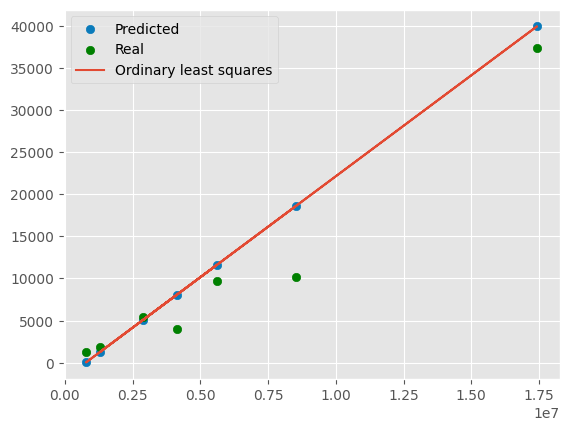

In [ ]:
fig, ax = plt.subplots()

ax.scatter(X_test, predictions, marker='o', color = "#0A7BBB", label="Predicted")
ax.scatter(X_test, y_test, marker='o', color = "green", label="Real")
ax.plot(X_test, predictions, label="Ordinary least squares")
ax.legend();